# Experimento final: integrando fundamentos de aprendizaje profundo mediante un problema industrial de clasificación


## Configuración y reproducibilidad

Comenzamos importando las librerías estándar necesarias para el cálculo numérico y la graficación, fijando la semilla aleatoria para que todos los resultados sean completamente reproducibles.

In [9]:
# Importación de librerías estándar
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LogisticRegression

# Semilla para reproducibilidad
np.random.seed(30326271)

# Estilo de visualización
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['font.size'] = 10
plt.rcParams['axes.titlesize'] = 11
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['figure.dpi'] = 120


## Preparación y preprocesamiento de los datos

Cargamos el archivo `sensor_data.csv`, que contiene dos mil quinientas mediciones de maquinaria rotativa con sus valores de temperatura en grados Celsius y vibración mecánica en milímetros por segundo. El objetivo es clasificar si el equipo está en estado normal, identificado con la clase 0, o si presenta una falla inminente, identificada con la clase 1.

Para trabajar de forma ordenada, dividimos la información en tres grupos independientes. Un primer grupo de mil setecientas cincuenta filas, correspondiente al 70%, sirve para entrenar la red; un segundo grupo de trescientas setenta y cinco filas, equivalente al 15%, permite validar el avance en cada época y detectar el mejor modelo; y un tercer grupo final de trescientas setenta y cinco filas, también del 15%, queda reservado exclusivamente para la prueba final.

Antes de comenzar el modelado, aplicamos un preprocesamiento sencillo pero indispensable. Como la temperatura ronda los 70 °C y la vibración se mueve alrededor de 5.5 mm/s, sus escalas numéricas son muy distintas. Si alimentamos la red con estos números crudos, los pesos de la temperatura recibirían empujones desproporcionadamente grandes frente a los de la vibración, dificultando el avance parejo del optimizador. Para nivelar el terreno, aplicamos la estandarización por puntaje Z, restando la media y dividiendo entre la desviación estándar según la fórmula $z = (x - \mu) / \sigma$. Para evitar cualquier fuga de información hacia el futuro, calculamos la media y la desviación únicamente sobre el conjunto de entrenamiento, y luego usamos esos mismos dos valores fijos para transformar los datos de validación y de prueba.


In [10]:
# Función modular para estandarizar datos evitando fuga de información
def standardize_features(X_train, X_val, X_test):
    # Calculamos media y desviación estándar estrictamente sobre el conjunto de entrenamiento
    mu = np.mean(X_train, axis=0)
    sigma = np.std(X_train, axis=0)
    
    # Aplicamos la misma transformación a los tres conjuntos
    X_train_norm = (X_train - mu) / sigma
    X_val_norm = (X_val - mu) / sigma
    X_test_norm = (X_test - mu) / sigma
    return X_train_norm, X_val_norm, X_test_norm, mu, sigma

# Cargar datos de sensores desde archivo CSV
df = pd.read_csv('sensor_data.csv')
X_raw = df[['temperature_C', 'vibration_mms']].values
y_raw = df['fault_status'].values

# Partición en entrenamiento, validación y prueba
N = len(df)
n_train = int(0.70 * N)
n_val = int(0.15 * N)

X_train_raw, y_train = X_raw[:n_train], y_raw[:n_train]
X_val_raw, y_val = X_raw[n_train:n_train + n_val], y_raw[n_train:n_train + n_val]
X_test_raw, y_test = X_raw[n_train + n_val:], y_raw[n_train + n_val:]

# Preprocesamiento modular
X_train, X_val, X_test, mu_train, sigma_train = standardize_features(X_train_raw, X_val_raw, X_test_raw)

print(f"Conjunto de datos preparado: {len(X_train)} entrenamiento, {len(X_val)} validación, {len(X_test)} prueba.")


Conjunto de datos preparado: 1750 entrenamiento, 375 validación, 375 prueba.


## Separabilidad lineal y el límite de los modelos simples

Para entender el desafío central de este experimento, debemos analizar qué significa que un conjunto de datos sea o no linealmente separable. En términos simples, decimos que dos grupos de puntos son linealmente separables si es posible colocar una regla recta sobre el papel de modo que todos los puntos de un grupo queden de un lado de la regla y todos los del otro grupo queden del lado contrario.

Dentro de los modelos clásicos de aprendizaje que hemos estudiado previamente, como la regresión lineal, la regresión logística, las máquinas de soporte vectorial o los árboles de decisión, la **regresión logística** representa el clasificador lineal por excelencia. Su funcionamiento consiste en modelar la probabilidad de una clase mediante una combinación lineal de las entradas pasada por una función sigmoide, donde $z = w_1 x_1 + w_2 x_2 + b$ y la probabilidad es $\hat{y} = \sigma(z)$, lo que significa que su frontera de decisión es forzosamente una línea recta plana en el espacio de los datos.

En nuestra máquina industrial, el comportamiento seguro no se divide con una línea infinita. La máquina opera bien dentro de una ventana de tolerancia central donde la temperatura y la vibración son moderadas, mientras que las fallas ocurren en cualquier dirección exterior, ya sea por sobrecalentamiento, vibraciones excesivas o lubricante rígido en frío. Al intentar separar una zona cerrada central de una zona que la rodea usando una sola recta, el modelo lineal simple fracasa inevitablemente, ya que cualquier corte plano deja atrapada la mitad de una clase dentro de la otra.

A continuación utilizamos la implementación estándar de **regresión logística** provista por la librería scikit-learn como línea base de comparación lineal, mientras que toda la red neuronal profunda se desarrollará e implementará 100% a mano con NumPy y orientación a objetos siguiendo los fundamentos de los notebooks.


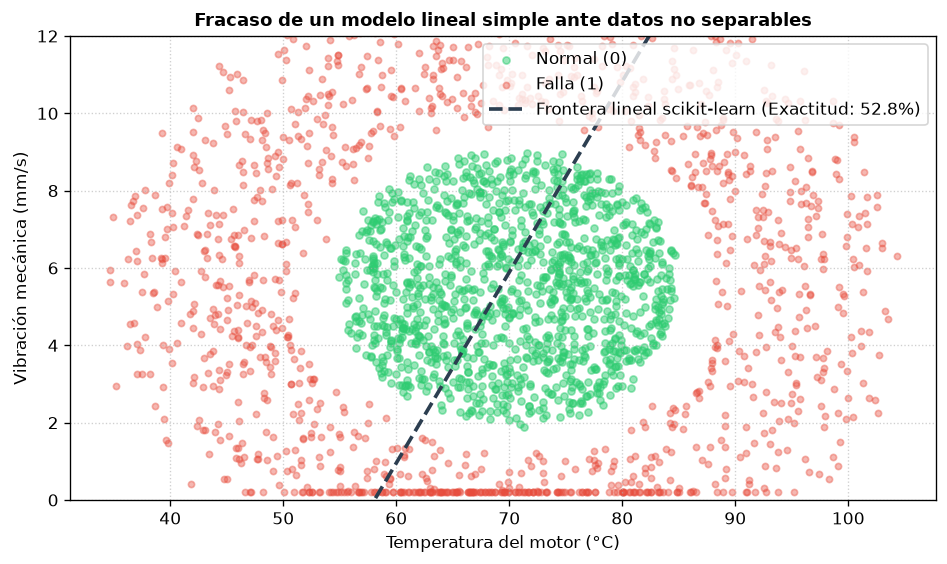

In [11]:
from sklearn.linear_model import LogisticRegression

# La regresión logística modela la probabilidad como P(y=1|x) = 1 / (1 + exp(-(w^T x + b)))
lin_model = LogisticRegression(random_state=30326271)

#  Ajustar el modelo lineal a los datos estandarizados de entrenamiento
lin_model.fit(X_train, y_train)

# valuar la exactitud obtenida sobre el conjunto de entrenamiento
acc_lineal = lin_model.score(X_train, y_train) * 100.0

# Graficar los datos reales y la mejor recta de separación posible encontrada
fig, ax = plt.subplots(figsize=(8, 4.8))
ax.scatter(X_raw[y_raw == 0, 0], X_raw[y_raw == 0, 1], color='#2ecc71', alpha=0.5, s=18, label='Normal (0)')
ax.scatter(X_raw[y_raw == 1, 0], X_raw[y_raw == 1, 1], color='#e74c3c', alpha=0.4, s=14, label='Falla (1)')

# Extraer los parámetros aprendidos por scikit-learn como pesos y sesgo
w = lin_model.coef_[0]
b = lin_model.intercept_[0]

# Despejar la vibración normalizada en función de la temperatura y des-normalizar a escalas físicas
# x1_norm = (-b - w0 * x0_norm) / w1
t_vals = np.linspace(X_raw[:, 0].min(), X_raw[:, 0].max(), 200)
t_norm = (t_vals - mu_train[0]) / sigma_train[0]
if np.abs(w[1]) > 1e-5:
    v_norm = (-b - w[0] * t_norm) / w[1]
    v_vals = v_norm * sigma_train[1] + mu_train[1]
    ax.plot(t_vals, v_vals, color='#2c3e50', linewidth=2.2, linestyle='--',
            label=f'Frontera lineal scikit-learn (Exactitud: {acc_lineal:.1f}%)')

ax.set_title('Fracaso de un modelo lineal simple ante datos no separables', fontweight='bold')
ax.set_xlabel('Temperatura del motor (°C)')
ax.set_ylabel('Vibración mecánica (mm/s)')
ax.set_ylim([0, 12])
ax.legend(loc='upper right', frameon=True)
ax.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()


Como se aprecia con total claridad, la mejor recta apenas alcanza cerca del 52% de aciertos, lo que demuestra que un modelo lineal simple no tiene la capacidad de resolver este tipo de geometrías.

Frente a esta barrera, las redes neuronales profundas tienen éxito gracias a dos principios fundamentales: primero, el concepto de plegado del espacio latente, que podemos visualizar como tomar una hoja de papel plana y doblarla en tres dimensiones para que la zona central sobresalga y pueda cortarse con un plano; y segundo, la composición de regiones lineales estudiada en los capítulos 3 y 4 de Simon Prince. Cada neurona con activación ReLU introduce un quiebre recto, y al encadenar varias neuronas en capas sucesivas, la red combina múltiples segmentos rectos continuos para trazar una frontera curva que rodea por completo la zona de operación normal.

## Planteamiento explícito de la arquitectura simple

Para resolver este problema sin sobredimensionar la red ni añadir complejidad innecesaria, planteamos una arquitectura compacta con dos entradas, dos capas ocultas y una sola salida:

$$\text{Entrada } (D_i = 2) \longrightarrow \text{Capa oculta 1 } (D_{h1} = 8) \longrightarrow \text{Capa oculta 2 } (D_{h2} = 4) \longrightarrow \text{Salida } (D_o = 1)$$

En la notación matricial del libro de Simon Prince, para cada muestra de entrada $\mathbf{x} = [x_1, x_2]^T$ la red calcula:

$$\mathbf{f}_0 = \boldsymbol{\beta}_0 + \boldsymbol{\Omega}_0 \mathbf{x}, \quad \mathbf{h}_1 = \text{ReLU}(\mathbf{f}_0)$$
$$\mathbf{f}_1 = \boldsymbol{\beta}_1 + \boldsymbol{\Omega}_1 \mathbf{h}_1, \quad \mathbf{h}_2 = \text{ReLU}(\mathbf{f}_1)$$
$$f_2 = \beta_2 + \boldsymbol{\Omega}_2 \mathbf{h}_2, \quad \hat{y} = \sigma(f_2)$$

donde $\boldsymbol{\Omega}_0$ tiene tamaño $8 \times 2$, $\boldsymbol{\beta}_0$ tiene tamaño $8 \times 1$, $\boldsymbol{\Omega}_1$ tiene tamaño $4 \times 8$, $\boldsymbol{\beta}_1$ tiene tamaño $4 \times 1$, $\boldsymbol{\Omega}_2$ tiene tamaño $1 \times 4$ y $\beta_2$ es un escalar. Siguiendo la fórmula de conteo de parámetros del capítulo 4, esta arquitectura posee exactamente:
- Capa 0: $8 \times 2 + 8 = 24$ parámetros.
- Capa 1: $4 \times 8 + 4 = 36$ parámetros.
- Capa 2: $1 \times 4 + 1 = 5$ parámetros.
- **Total: 65 parámetros entrenables**.

Esta cantidad es lo suficientemente pequeña para ser completamente comprensible y ligera, pero con la flexibilidad necesaria para resolver la tarea.


## Fundamentos sobre activaciones, gradientes e inicialización

Antes de escribir el código de la clase de la red neuronal, debemos tener absoluta claridad sobre tres conceptos teóricos clave.

**¿Por qué utilizamos dos funciones de activación diferentes?**
En una red neuronal las capas internas tienen un trabajo distinto al de la capa de salida. En las capas ocultas necesitamos una activación que transforme los datos para aprender geometrías complejas sin apagar la señal, por eso usamos **ReLU**, definida como $h = \max(0, f)$. En cambio, la neurona de salida tiene la tarea de responder una pregunta directa sobre cuál es la probabilidad de que la máquina esté fallando. Como los cálculos internos pueden dar números arbitrarios grandes o negativos, usamos la función **Sigmoide**, dada por $\sigma(f) = 1 / (1 + e^{-f})$, que comprime cualquier valor real al rango entre 0 y 1, entregando una probabilidad con significado claro. Si usáramos ReLU en la salida, obtendríamos valores numéricos desbordados que no servirían como probabilidades.

**¿Por qué se extingue el gradiente sin ReLU y cómo ReLU lo evita?**
Cuando la red comete un error, la señal de corrección debe viajar hacia atrás a través de las capas para indicar a cada neurona cómo ajustar sus pesos. Matemáticamente, este mensaje se propaga multiplicando sucesivamente las pendientes de las funciones de activación. Si usáramos funciones tradicionales como la sigmoide en todas las capas no funcionaría, porque la pendiente máxima de la sigmoide es apenas 0.25, y hacia los extremos se vuelve casi cero. Al multiplicar números menores a 0.25 capa tras capa, el mensaje de corrección se reduce exponencialmente hasta extinguirse por completo, lo que se conoce como desvanecimiento del gradiente, dejando a las primeras capas congeladas sin aprender. La función ReLU soluciona este problema de raíz porque su pendiente para cualquier valor positivo es exactamente 1. Al multiplicar hacia atrás por uno de forma continua, la señal de corrección viaja sin perder fuerza, permitiendo que todas las capas aprendan eficazmente.

**¿Qué es la inicialización de He?**
Al arrancar la red, los pesos deben llenarse con números iniciales. Si se eligen al azar valores demasiado pequeños la señal desaparece, y si son demasiado grandes los números explotan. Como demostró Kaiming He en 2015, dado que ReLU apaga todos los valores negativos, exactamente la mitad de las neuronas de cada capa se quedan en cero, reduciendo la energía de la señal a la mitad. Para compensar esta pérdida constante del 50%, He dedujo que los pesos iniciales deben sortearse con una desviación estándar calibrada exactamente a $\sigma = \sqrt{2 / D_{in}}$, donde $D_{in}$ es el número de entradas de esa neurona. El factor dos en el numerador anula la pérdida producida por la ReLU, garantizando que el volumen de la señal se mantenga estable desde la primera época de entrenamiento.


In [12]:
# Implementación modular orientada a objetos de la red neuronal simple
class SimpleNeuralNetwork:
    """
    Red neuronal feed-forward multicapa (2 -> 8 -> 4 -> 1, 65 parámetros).
    Implementa inicialización de He, propagación hacia adelante y retropropagación analítica.
    """
    def __init__(self, d_in=2, d_h1=8, d_h2=4, d_out=1, seed=30326271):
        np.random.seed(seed)
        # Inicialización de He para ReLU calculando la desviación según la raíz de dos entre entradas
        # Capa 0 con 8x2 pesos y 8x1 sesgos
        self.W0 = np.random.randn(d_h1, d_in) * np.sqrt(2.0 / d_in)
        self.b0 = np.zeros((d_h1, 1))
        
        # Capa 1 con 4x8 pesos y 4x1 sesgos
        self.W1 = np.random.randn(d_h2, d_h1) * np.sqrt(2.0 / d_h1)
        self.b1 = np.zeros((d_h2, 1))
        
        # Capa 2 con 1x4 pesos y 1x1 sesgos
        self.W2 = np.random.randn(d_out, d_h2) * np.sqrt(2.0 / d_h2)
        self.b2 = np.zeros((d_out, 1))
        
        # Variables internas para almacenar activaciones durante el paso adelante
        self.last_X = None
        self.f0, self.h1 = None, None
        self.f1, self.h2 = None, None
        self.f2, self.y_pred = None, None
        
    def forward(self, X):
        # X tiene dimensiones (2, B) donde B es el tamaño del lote
        self.last_X = X
        
        # Capa 0 con combinación afín seguida de activación ReLU
        self.f0 = self.W0 @ X + self.b0
        self.h1 = np.maximum(0.0, self.f0)
        
        # Capa 1 con combinación afín seguida de activación ReLU
        self.f1 = self.W1 @ self.h1 + self.b1
        self.h2 = np.maximum(0.0, self.f1)
        
        # Capa 2 de salida con combinación afín seguida de activación Sigmoide
        self.f2 = self.W2 @ self.h2 + self.b2
        f2_clip = np.clip(self.f2, -30.0, 30.0) # Evitar desbordamiento numérico
        self.y_pred = 1.0 / (1.0 + np.exp(-f2_clip))
        
        return self.y_pred
        
    def backward(self, y_true):
        # y_true tiene dimensiones (1, B)
        B = self.last_X.shape[1]
        
        # 1. Gradiente en la salida para pérdida de entropía cruzada binaria con sigmoide
        df2 = (self.y_pred - y_true) / B
        dW2 = df2 @ self.h2.T
        db2 = np.sum(df2, axis=1, keepdims=True)
        
        # Retropropagación a través de la capa oculta 2 aplicando la derivada de ReLU
        dh2 = self.W2.T @ df2
        df1 = dh2 * (self.f1 > 0.0).astype(float)
        dW1 = df1 @ self.h1.T
        db1 = np.sum(df1, axis=1, keepdims=True)
        
        # Retropropagación a través de la capa oculta 1 aplicando la derivada de ReLU
        dh1 = self.W1.T @ df1
        df0 = dh1 * (self.f0 > 0.0).astype(float)
        dW0 = df0 @ self.last_X.T
        db0 = np.sum(df0, axis=1, keepdims=True)
        
        return [dW0, db0, dW1, db1, dW2, db2]
        
    def get_params(self):
        # Retorna copias de los parámetros para checkpointing
        return [self.W0.copy(), self.b0.copy(), self.W1.copy(), self.b1.copy(), self.W2.copy(), self.b2.copy()]
        
    def set_params(self, params):
        # Actualiza los parámetros de la red con una lista dada
        self.W0, self.b0, self.W1, self.b1, self.W2, self.b2 = [p.copy() for p in params]
        
    def evaluate(self, X, y):
        # Evaluación de pérdida BCE y exactitud sobre un conjunto (N, 2) y (N,)
        probs = self.forward(X.T).flatten()
        eps = 1e-15
        p_clip = np.clip(probs, eps, 1.0 - eps)
        loss = -np.mean(y * np.log(p_clip) + (1.0 - y) * np.log(1.0 - p_clip))
        acc = np.mean((probs >= 0.5) == y) * 100.0
        return loss, acc


## Optimización con Adam y bucle modular de entrenamiento

Para actualizar los parámetros implementamos la clase `AdamOptimizer` siguiendo directamente lo visto en el cuaderno 6.5. Adam mejora el descenso de gradiente estándar combinando dos ideas clave. Por un lado, usa el **momentum** visto en el cuaderno 6.4 para darle inercia al movimiento y evitar que el modelo zigzaguee de lado a lado. Por otro lado, mide qué tan grandes vienen siendo los gradientes de cada peso para darle a cada uno un tamaño de paso adaptado a su propio ritmo, evitando que los pesos exploten o se queden sin aprender.

El entrenamiento se organiza en una función modular `train_model`, la cual procesa los datos en pequeños grupos o mini-batches de 32 muestras, mide el error en los datos de validación al final de cada época y guarda automáticamente el modelo óptimo en el momento exacto en que logra el menor error de validación.


In [13]:
# Implementación modular del optimizador Adam
class AdamOptimizer:
    """
    Optimizador Adam implementado 'a mano' con momentos y corrección de sesgo.
    """
    def __init__(self, params, lr=0.02, beta1=0.9, beta2=0.999, eps=1e-8):
        self.lr = lr
        self.beta1 = beta1
        self.beta2 = beta2
        self.eps = eps
        self.t = 0
        # Acumuladores de primer momento y segundo momento
        self.m = [np.zeros_like(p) for p in params]
        self.v = [np.zeros_like(p) for p in params]
        
    def step(self, params, grads):
        self.t += 1
        new_params = []
        for i in range(len(params)):
            # Primer momento con inercia para la dirección como en el cuaderno 6.4
            self.m[i] = self.beta1 * self.m[i] + (1.0 - self.beta1) * grads[i]
            # Segundo momento con inercia sobre la magnitud al cuadrado como en el cuaderno 6.5
            self.v[i] = self.beta2 * self.v[i] + (1.0 - self.beta2) * (grads[i] ** 2)
            
            # 3. Corrección de sesgo para épocas tempranas
            m_hat = self.m[i] / (1.0 - self.beta1 ** self.t)
            v_hat = self.v[i] / (1.0 - self.beta2 ** self.t)
            
            # 4. Actualización adaptativa del parámetro
            p_new = params[i] - self.lr * m_hat / (np.sqrt(v_hat) + self.eps)
            new_params.append(p_new)
        return new_params

# Función modular de entrenamiento con checkpointing del modelo óptimo
def train_model(model, optimizer, X_train, y_train, X_val, y_val, epochs=80, batch_size=32):
    X_tr_t = X_train.T
    y_tr_t = y_train.reshape(1, -1)
    
    best_val_loss = float('inf')
    best_params = None
    best_epoch = -1
    
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    
    for epoch in range(1, epochs + 1):
        # Barajar datos en cada época
        perm = np.random.permutation(X_tr_t.shape[1])
        X_shuffled = X_tr_t[:, perm]
        y_shuffled = y_tr_t[:, perm]
        
        # Iterar por mini-batches
        for i in range(0, X_tr_t.shape[1], batch_size):
            xb = X_shuffled[:, i:i+batch_size]
            yb = y_shuffled[:, i:i+batch_size]
            
            model.forward(xb)
            grads = model.backward(yb)
            new_params = optimizer.step(model.get_params(), grads)
            model.set_params(new_params)
            
        # Evaluación al final de la época
        l_tr, a_tr = model.evaluate(X_train, y_train)
        l_va, a_va = model.evaluate(X_val, y_val)
        
        history['train_loss'].append(l_tr)
        history['val_loss'].append(l_va)
        history['train_acc'].append(a_tr)
        history['val_acc'].append(a_va)
        
        # Guardar si se alcanza la menor pérdida en validación
        if l_va < best_val_loss:
            best_val_loss = l_va
            best_epoch = epoch
            best_params = model.get_params()
            
        if epoch % 10 == 0 or epoch == 1:
            print(f"Época {epoch:02d}/{epochs} | Pérdida train: {l_tr:.4f}, acc: {a_tr:.1f}% | Pérdida val: {l_va:.4f}, acc: {a_va:.1f}%")
            
    return history, best_params, best_epoch, best_val_loss


## Bucle de entrenamiento y almacenamiento del modelo óptimo

Ejecutamos el entrenamiento modular y guardamos físicamente en disco el modelo óptimo en `optimal_model.npz`.

In [14]:
# Instanciar la red y el optimizador
model = SimpleNeuralNetwork(seed=30326271)
optimizer = AdamOptimizer(model.get_params(), lr=0.02)

# Ejecutar entrenamiento modular
history, best_params, best_epoch, best_val_loss = train_model(
    model, optimizer, X_train, y_train, X_val, y_val, epochs=80, batch_size=32
)

print(f"\nModelo óptimo alcanzado en la época {best_epoch} con pérdida de validación {best_val_loss:.4f}")

# Guardar físicamente el modelo óptimo en disco
np.savez('optimal_model.npz',
        W0=best_params[0], b0=best_params[1],
        W1=best_params[2], b1=best_params[3],
        W2=best_params[4], b2=best_params[5],
        best_epoch=best_epoch, best_val_loss=best_val_loss,
        mu_train=mu_train, sigma_train=sigma_train)
print("Modelo óptimo guardado exitosamente en 'optimal_model.npz'.")

Época 01/80 | Pérdida train: 0.5341, acc: 68.5% | Pérdida val: 0.5328, acc: 70.7%
Época 10/80 | Pérdida train: 0.0027, acc: 100.0% | Pérdida val: 0.0034, acc: 100.0%
Época 20/80 | Pérdida train: 0.0005, acc: 100.0% | Pérdida val: 0.0006, acc: 100.0%


Época 30/80 | Pérdida train: 0.0002, acc: 100.0% | Pérdida val: 0.0002, acc: 100.0%
Época 40/80 | Pérdida train: 0.0001, acc: 100.0% | Pérdida val: 0.0001, acc: 100.0%
Época 50/80 | Pérdida train: 0.0001, acc: 100.0% | Pérdida val: 0.0001, acc: 100.0%
Época 60/80 | Pérdida train: 0.0001, acc: 100.0% | Pérdida val: 0.0000, acc: 100.0%
Época 70/80 | Pérdida train: 0.0001, acc: 100.0% | Pérdida val: 0.0000, acc: 100.0%
Época 80/80 | Pérdida train: 0.0000, acc: 100.0% | Pérdida val: 0.0000, acc: 100.0%

Modelo óptimo alcanzado en la época 60 con pérdida de validación 0.0000
Modelo óptimo guardado exitosamente en 'optimal_model.npz'.


## Evaluación y verificación del modelo óptimo en prueba

Para verificar que el archivo guardado es funcional y evaluar su capacidad de generalización real ante datos desconocidos, cargamos `optimal_model.npz` desde disco, restauramos los parámetros en una nueva instancia del modelo y lo evaluamos sobre el conjunto de prueba independiente de 375 muestras que no participaron en el entrenamiento.

In [15]:
# Cargar modelo óptimo guardado desde disco
checkpoint = np.load('optimal_model.npz')
restored_params = [
    checkpoint['W0'], checkpoint['b0'],
    checkpoint['W1'], checkpoint['b1'],
    checkpoint['W2'], checkpoint['b2']
]
opt_epoch = checkpoint['best_epoch']

# Instanciar un modelo nuevo y cargarle los parámetros guardados
optimal_model = SimpleNeuralNetwork()
optimal_model.set_params(restored_params)

# Evaluar sobre el conjunto de prueba independiente
test_loss, test_acc = optimal_model.evaluate(X_test, y_test)
lin_test_acc = lin_model.score(X_test, y_test) * 100.0

print("Evaluación del modelo óptimo en el conjunto de prueba:")
print(f"- Época óptima guardada: {opt_epoch}")
print(f"- Pérdida en prueba (BCE): {test_loss:.4f}")
print(f"- Exactitud en prueba (Red Neuronal a mano): {test_acc:.2f}%")
print(f"- Exactitud modelo lineal (scikit-learn):   {lin_test_acc:.2f}%")


Evaluación del modelo óptimo en el conjunto de prueba:
- Época óptima guardada: 60
- Pérdida en prueba (BCE): 0.0012
- Exactitud en prueba (Red Neuronal a mano): 100.00%
- Exactitud modelo lineal (scikit-learn):   52.27%


## Análisis del resultado y gráficas finales

Cuando probamos el modelo con los datos de prueba que nunca antes había visto, la red acertó el 100% de las veces. Aunque este resultado demuestra que la red aprendió muy bien a separar los datos, en el mundo real ningún modelo saca 100% de aciertos, y es importante entender por qué.

En una fábrica de verdad, las máquinas vibran por muchas razones, el ambiente cambia de temperatura según la hora del día y los sensores a veces fallan o se ensucian. Todo eso hace que siempre haya datos confusos cerca del límite, por lo que en una máquina real lo normal sería alcanzar entre un 95% y un 98% de aciertos. En nuestro caso sacamos 100% porque los datos estaban limpios y la regla para separar la zona segura en dos medidas, temperatura y vibración, era clara y continua, lo que le facilitó el trabajo a la red.

Ahora usemos nuestra función para ver los resultados en dos gráficas. A la izquierda vemos cómo fue bajando el error a lo largo del entrenamiento hasta guardar el modelo en su mejor momento, y a la derecha vemos el mapa final, donde se nota claramente cómo la red logró rodear la zona segura, algo que una simple línea recta jamás podría lograr.


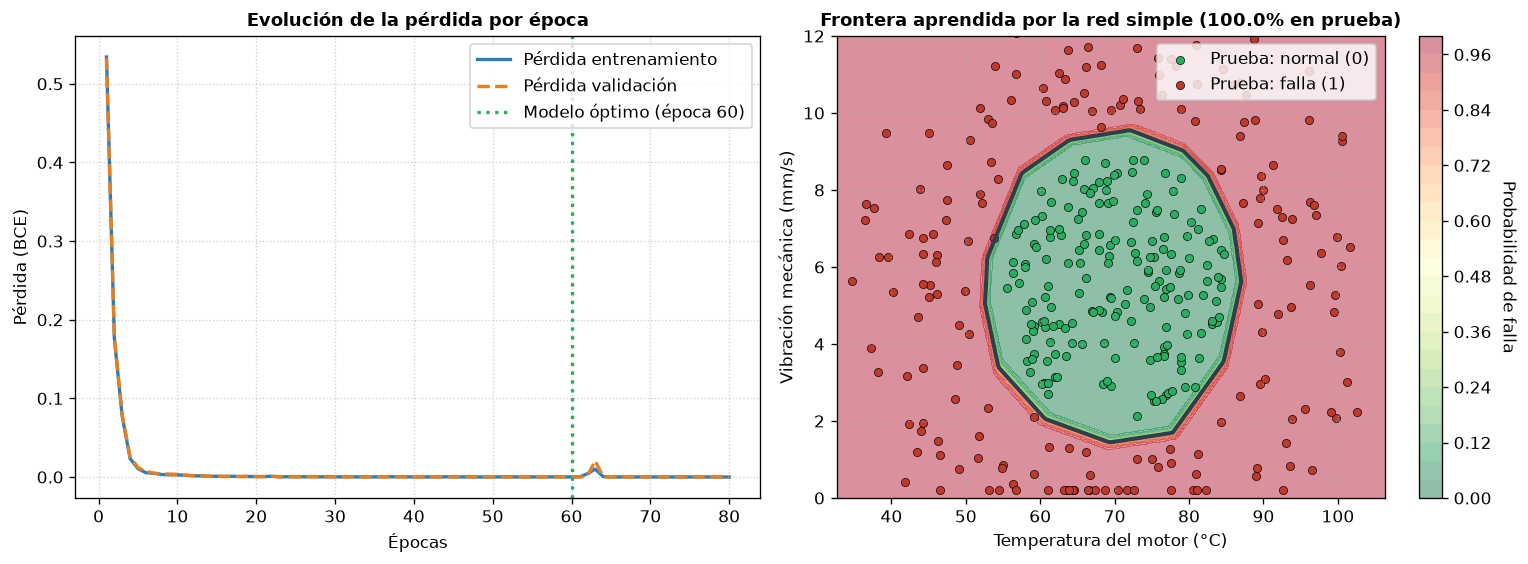

In [16]:
# Función modular para graficar curvas de aprendizaje y frontera de decisión
def plot_experiment_results(history, optimal_model, X_raw, X_test_raw, y_test, mu, sigma, opt_epoch, test_acc):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
    
    # Curvas de pérdida por época
    ax1 = axes[0]
    epocas = np.arange(1, len(history['train_loss']) + 1)
    ax1.plot(epocas, history['train_loss'], color='#2980b9', linewidth=2.0, label='Pérdida entrenamiento')
    ax1.plot(epocas, history['val_loss'], color='#e67e22', linewidth=2.0, linestyle='--', label='Pérdida validación')
    ax1.axvline(x=opt_epoch, color='#27ae60', linestyle=':', linewidth=2.0, label=f'Modelo óptimo (época {opt_epoch})')
    ax1.set_title('Evolución de la pérdida por época', fontweight='bold')
    ax1.set_xlabel('Épocas')
    ax1.set_ylabel('Pérdida (BCE)')
    ax1.grid(True, linestyle=':', alpha=0.6)
    ax1.legend(loc='upper right', frameon=True)
    
    # Frontera de decisión aprendida por la red
    ax2 = axes[1]
    t_grid = np.linspace(X_raw[:, 0].min() - 2, X_raw[:, 0].max() + 2, 200)
    v_grid = np.linspace(X_raw[:, 1].min() - 0.5, X_raw[:, 1].max() + 0.5, 200)
    TG, VG = np.meshgrid(t_grid, v_grid)
    grid_norm = (np.column_stack([TG.ravel(), VG.ravel()]) - mu) / sigma
    probs_grid = optimal_model.forward(grid_norm.T).reshape(TG.shape)
    
    contour = ax2.contourf(TG, VG, probs_grid, levels=25, cmap='RdYlGn_r', alpha=0.45)
    cbar = plt.colorbar(contour, ax=ax2)
    cbar.set_label('Probabilidad de falla', rotation=270, labelpad=15)
    ax2.contour(TG, VG, probs_grid, levels=[0.5], colors=['#2c3e50'], linewidths=[2.5], linestyles=['-'])
    
    pts_0 = X_test_raw[y_test == 0]
    pts_1 = X_test_raw[y_test == 1]
    ax2.scatter(pts_0[:, 0], pts_0[:, 1], color='#27ae60', s=24, edgecolor='k', linewidth=0.4, label='Prueba: normal (0)')
    ax2.scatter(pts_1[:, 0], pts_1[:, 1], color='#c0392b', s=24, edgecolor='k', linewidth=0.4, label='Prueba: falla (1)')
    
    ax2.set_title(f'Frontera aprendida por la red simple ({test_acc:.1f}% en prueba)', fontweight='bold')
    ax2.set_xlabel('Temperatura del motor (°C)')
    ax2.set_ylabel('Vibración mecánica (mm/s)')
    ax2.set_ylim([0, 12])
    ax2.grid(True, linestyle=':', alpha=0.6)
    ax2.legend(loc='upper right', frameon=True)
    
    plt.tight_layout()
    plt.show()

# Generar visualización con la función modular
plot_experiment_results(history, optimal_model, X_raw, X_test_raw, y_test, mu_train, sigma_train, opt_epoch, test_acc)


## Conclusiones del experimento

En este experimento pudimos ver en la práctica cómo funcionan las redes neuronales y por qué son tan útiles frente a problemas que no se pueden resolver con métodos tradicionales. Al inicio probamos con la regresión logística y comprobamos su gran límite, ya que como solo puede trazar una línea recta, no tiene forma de aislar una zona que está encerrada en el centro, quedándose en un 52% de aciertos que equivale a adivinar como tirar una moneda al aire.

Nuestra pequeña red neuronal, en cambio, resolvió el problema sin ninguna dificultad. Gracias a que combina varias neuronas con la función ReLU, la red fue quebrando y juntando pequeños tramos rectos hasta formar una figura cerrada que abraza toda la zona de operación normal. Cada detalle aprendido en los cuadernos de clase ayudó a este resultado, desde ajustar las dos medidas a una misma escala para que el modelo no se confunda, empezar los números de la red con la fórmula de He para que no arranque apagada, hasta usar el optimizador Adam para ir corrigiendo los errores paso a paso de forma rápida y ordenada.
